In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

proteomics_path = Path("/data484_4/txia2/mocov2/proWAS/proteomics_above_mean_LOD_mean.csv")
trait_dir = Path("/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2/partial_fit_5std")
ukb_all_path = Path("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv")
output_dir = Path("/data484_4/txia2/mocov2/proWAS/prowas_brain_LOD_mean")
output_dir.mkdir(parents=True, exist_ok=True)

alpha = 0.05
min_protein_samples = 10000  # Filter to proteins with > 10000 samples
min_regression_samples = 1000  # Minimum merged samples required per regression

# --- Helper utilities ------------------------------------------------------
def _pick_field(field_id: str, available_cols: list[str], preferred_instances: tuple[str, ...]) -> str | None:
    """Return the first column that matches the UKB field id and preferred instance."""
    matches = [c for c in available_cols if c.startswith(f"{field_id}-")]
    if not matches:
        return None
    for suffix in preferred_instances:
        candidate = f"{field_id}-{suffix}"
        if candidate in matches:
            return candidate
    return matches[0]

# Field IDs requested for the brain ProWAS run.
brain_field_specs = {
    "age": ("21003", ("2.0", "0.0", "1.0", "3.0")),
    "sex": ("31", ("0.0", "2.0", "1.0", "3.0")),
    "scanner_lateral": ("25756", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_transverse": ("25757", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_longitudinal": ("25758", ("2.0", "3.0", "0.0", "1.0")),
    "head_motion": ("25741", ("2.0", "3.0", "0.0", "1.0")),
    "intracranial_volume": ("25000", ("2.0", "3.0", "0.0", "1.0")),
    "body_weight": ("21002", ("2.0", "0.0", "1.0", "3.0")),
    "height": ("50", ("2.0", "0.0", "1.0", "3.0")),
    "waist_circumference": ("48", ("2.0", "0.0", "1.0", "3.0")),
    "bmi": ("23104", ("2.0", "0.0", "1.0", "3.0")),
    "assessment_centre": ("54", ("2.0", "0.0", "1.0", "3.0")),
}

ukb_columns = list(pd.read_csv(ukb_all_path, nrows=0).columns)
field_to_column: dict[str, str] = {}
missing_covars: list[str] = []
ukb_usecols = {"eid"}
for covar, (field_id, preferred_instances) in brain_field_specs.items():
    column = _pick_field(field_id, ukb_columns, preferred_instances)
    if column is None:
        missing_covars.append(covar)
        continue
    field_to_column[covar] = column
    ukb_usecols.add(column)

pc_candidates = sorted([c for c in ukb_columns if c.startswith("22009-0.")], key=lambda x: int(x.split(".")[-1]))
pc_columns = pc_candidates[:40]
for idx, column in enumerate(pc_columns, start=1):
    name = f"pc{idx}"
    field_to_column[name] = column
    ukb_usecols.add(column)

if missing_covars:
    print("Missing covariate columns in UKB_all.csv:", ", ".join(missing_covars))

covars = pd.read_csv(ukb_all_path, usecols=sorted(ukb_usecols))
covars["eid"] = covars["eid"].astype(int)
covars = covars.rename(columns={v: k for k, v in field_to_column.items()})

categorical_covars = [c for c in ["sex", "assessment_centre"] if c in covars.columns]
continuous_covars = [c for c in [
    "age",
    "scanner_lateral",
    "scanner_transverse",
    "scanner_longitudinal",
    "head_motion",
    "intracranial_volume",
    "body_weight",
    "height",
    "waist_circumference",
    "bmi",
] if c in covars.columns]
continuous_covars.extend([f"pc{i}" for i in range(1, len(pc_columns) + 1)])

proteomics = pd.read_csv(proteomics_path)
proteomics["eid"] = proteomics["eid"].astype(int)
rename_map = {}
batch_cols = [c for c in proteomics.columns if "batch" in c.lower()]
if batch_cols:
    rename_map[batch_cols[0]] = "protein_batch"
lod_cols = [c for c in proteomics.columns if "lod" in c.lower()]
if lod_cols:
    rename_map[lod_cols[0]] = "lod"
proteomics = proteomics.rename(columns=rename_map)
meta_cols = ["eid"] + list(rename_map.values())
protein_columns = [c for c in proteomics.columns if c not in meta_cols]

# Filter proteins to only those with > min_samples non-NaN values
print(f"Filtering proteins to those with > {min_protein_samples} samples...")
protein_sample_counts = proteomics[protein_columns].notna().sum()
valid_proteins = protein_sample_counts[protein_sample_counts > min_protein_samples].index.tolist()
print(f"Found {len(valid_proteins)} proteins with > {min_protein_samples} samples (out of {len(protein_columns)} total)")
protein_columns = valid_proteins

if "lod" in proteomics.columns and "lod" not in continuous_covars:
    continuous_covars.append("lod")
if "protein_batch" in proteomics.columns and "protein_batch" not in categorical_covars:
    categorical_covars.append("protein_batch")

trait_files = sorted(trait_dir.glob("Feature_*.csv"))
print(f"Found {len(protein_columns)} proteins (filtered to > {min_protein_samples} samples) and {len(trait_files)} trait files.")
bonferroni_factor = max(len(protein_columns) * max(len(trait_files), 1), 1)
print(f"Bonferroni correction factor: {bonferroni_factor}")

all_trait_results: list[pd.DataFrame] = []
for trait_path in trait_files:
    trait_df = pd.read_csv(trait_path, sep=r'\s+')
    trait_cols = [c for c in trait_df.columns if c.upper() not in {"FID", "IID"}]
    if not trait_cols:
        continue
    trait_name = trait_cols[0]
    trait_df = trait_df.rename(columns={"IID": "eid"})
    trait_df["eid"] = trait_df["eid"].astype(int)
    trait_df = trait_df[["eid", trait_name]].drop_duplicates("eid")

    merged = (
        proteomics.merge(trait_df, on="eid", how="inner")
        .merge(covars, on="eid", how="inner")
    )

    if merged.empty:
        print(f"Skipping {trait_path.name} (no overlapping subjects).")
        continue

    local_cont = [c for c in continuous_covars if c in merged.columns]
    local_cat = [c for c in categorical_covars if c in merged.columns]

    numeric_design = merged[[trait_name] + local_cont].apply(pd.to_numeric, errors="coerce")
    cat_frames = []
    for col in local_cat:
        cat_frames.append(pd.get_dummies(merged[col].fillna("missing"), prefix=col, drop_first=True))
    design_matrix = pd.concat([numeric_design] + cat_frames, axis=1)
    design_matrix = design_matrix.dropna()
    if design_matrix.empty:
        print(f"Skipping {trait_path.name} (no rows after covariate filtering).")
        continue

    # Ensure all columns are numeric (convert any remaining object dtypes)
    for col in design_matrix.columns:
        if design_matrix[col].dtype == 'object':
            design_matrix[col] = pd.to_numeric(design_matrix[col], errors='coerce')
    
    X = sm.add_constant(design_matrix, has_constant="add")
    # Convert to numpy array to ensure numeric types
    X_array = X.values.astype(float)
    design_index = X.index

    trait_results = []
    for protein in protein_columns:
        y = merged.loc[design_index, protein].apply(pd.to_numeric, errors="coerce")
        valid_mask = y.notna()
        n_valid = valid_mask.sum()
        required_samples = max(len(X.columns) + 1, min_regression_samples)
        if n_valid < required_samples:
            continue
        
        # Ensure y is numeric array
        y_array = y[valid_mask].values.astype(float)
        X_subset = X_array[valid_mask.values]
        
        # Check for any remaining NaN or inf values
        if np.any(~np.isfinite(y_array)) or np.any(~np.isfinite(X_subset)):
            continue
            
        try:
            model = sm.OLS(y_array, X_subset).fit()
        except (ValueError, np.linalg.LinAlgError) as e:
            continue
        
        # Get the index of trait_name in the design matrix (after constant)
        # X has constant first, then trait_name, then other covariates
        trait_idx = None
        for idx, col in enumerate(X.columns):
            if col == trait_name:
                trait_idx = idx
                break
        
        if trait_idx is None:
            continue
            
        beta = model.params[trait_idx] if trait_idx < len(model.params) else np.nan
        p_value = model.pvalues[trait_idx] if trait_idx < len(model.pvalues) else np.nan
        
        if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
            continue
        trait_results.append({
            "trait": trait_name,
            "trait_file": trait_path.name,
            "protein": protein,
            "n_samples": int(n_valid),
            "beta": beta,
            "p_value": p_value,
        })

    if not trait_results:
        print(f"No valid regressions for {trait_path.name}.")
        continue

    trait_df_out = pd.DataFrame(trait_results)
    trait_df_out["bonferroni_p"] = np.minimum(trait_df_out["p_value"] * bonferroni_factor, 1.0)
    trait_df_out = trait_df_out.sort_values("p_value")
    trait_df_out.to_csv(output_dir / f"{trait_name}_prowas.csv", index=False)
    all_trait_results.append(trait_df_out)
    print(f"Finished {trait_path.name}: {len(trait_df_out)} protein tests saved.")

if all_trait_results:
    combined = pd.concat(all_trait_results, ignore_index=True)
    combined.to_csv(output_dir / "brain_prowas_all_traits.csv", index=False)
    print("Combined results saved.")
else:
    print("No trait results were generated. Check covariate coverage and inputs.")



Missing covariate columns in UKB_all.csv: head_motion, bmi
Filtering proteins to those with > 10000 samples...
Found 2457 proteins with > 10000 samples (out of 2922 total)
Found 2457 proteins (filtered to > 10000 samples) and 128 trait files.
Bonferroni correction factor: 314496
Finished Feature_0.csv: 2272 protein tests saved.
Finished Feature_1.csv: 2272 protein tests saved.
Finished Feature_10.csv: 2272 protein tests saved.
Finished Feature_100.csv: 2272 protein tests saved.
Finished Feature_101.csv: 2272 protein tests saved.
Finished Feature_102.csv: 2272 protein tests saved.
Finished Feature_103.csv: 2272 protein tests saved.
Finished Feature_104.csv: 2272 protein tests saved.
Finished Feature_105.csv: 2272 protein tests saved.
Finished Feature_106.csv: 2272 protein tests saved.
Finished Feature_107.csv: 2272 protein tests saved.
Finished Feature_108.csv: 2272 protein tests saved.
Finished Feature_109.csv: 2272 protein tests saved.
Finished Feature_11.csv: 2272 protein tests saved

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm

proteomics_path = Path("/data484_4/txia2/mocov2/proWAS/proteomics_above_mean_LOD_mean.csv")
trait_dir = Path("/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2_T2_5std")
ukb_all_path = Path("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv")
output_dir = Path("/data484_4/txia2/mocov2/proWAS/prowas_brain_T2_LOD_mean")
output_dir.mkdir(parents=True, exist_ok=True)

alpha = 0.05
min_protein_samples = 10000  # Filter to proteins with > 10000 samples
min_regression_samples = 1000  # Minimum merged samples required per regression

# --- Helper utilities ------------------------------------------------------
def _pick_field(field_id: str, available_cols: list[str], preferred_instances: tuple[str, ...]) -> str | None:
    """Return the first column that matches the UKB field id and preferred instance."""
    matches = [c for c in available_cols if c.startswith(f"{field_id}-")]
    if not matches:
        return None
    for suffix in preferred_instances:
        candidate = f"{field_id}-{suffix}"
        if candidate in matches:
            return candidate
    return matches[0]

# Field IDs requested for the brain ProWAS run.
brain_field_specs = {
    "age": ("21003", ("2.0", "0.0", "1.0", "3.0")),
    "sex": ("31", ("0.0", "2.0", "1.0", "3.0")),
    "scanner_lateral": ("25756", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_transverse": ("25757", ("2.0", "3.0", "0.0", "1.0")),
    "scanner_longitudinal": ("25758", ("2.0", "3.0", "0.0", "1.0")),
    "head_motion": ("25741", ("2.0", "3.0", "0.0", "1.0")),
    "intracranial_volume": ("25000", ("2.0", "3.0", "0.0", "1.0")),
    "body_weight": ("21002", ("2.0", "0.0", "1.0", "3.0")),
    "height": ("50", ("2.0", "0.0", "1.0", "3.0")),
    "waist_circumference": ("48", ("2.0", "0.0", "1.0", "3.0")),
    "bmi": ("23104", ("2.0", "0.0", "1.0", "3.0")),
    "assessment_centre": ("54", ("2.0", "0.0", "1.0", "3.0")),
}

ukb_columns = list(pd.read_csv(ukb_all_path, nrows=0).columns)
field_to_column: dict[str, str] = {}
missing_covars: list[str] = []
ukb_usecols = {"eid"}
for covar, (field_id, preferred_instances) in brain_field_specs.items():
    column = _pick_field(field_id, ukb_columns, preferred_instances)
    if column is None:
        missing_covars.append(covar)
        continue
    field_to_column[covar] = column
    ukb_usecols.add(column)

pc_candidates = sorted([c for c in ukb_columns if c.startswith("22009-0.")], key=lambda x: int(x.split(".")[-1]))
pc_columns = pc_candidates[:40]
for idx, column in enumerate(pc_columns, start=1):
    name = f"pc{idx}"
    field_to_column[name] = column
    ukb_usecols.add(column)

if missing_covars:
    print("Missing covariate columns in UKB_all.csv:", ", ".join(missing_covars))

covars = pd.read_csv(ukb_all_path, usecols=sorted(ukb_usecols))
covars["eid"] = covars["eid"].astype(int)
covars = covars.rename(columns={v: k for k, v in field_to_column.items()})

categorical_covars = [c for c in ["sex", "assessment_centre"] if c in covars.columns]
continuous_covars = [c for c in [
    "age",
    "scanner_lateral",
    "scanner_transverse",
    "scanner_longitudinal",
    "head_motion",
    "intracranial_volume",
    "body_weight",
    "height",
    "waist_circumference",
    "bmi",
] if c in covars.columns]
continuous_covars.extend([f"pc{i}" for i in range(1, len(pc_columns) + 1)])

proteomics = pd.read_csv(proteomics_path)
proteomics["eid"] = proteomics["eid"].astype(int)
rename_map = {}
batch_cols = [c for c in proteomics.columns if "batch" in c.lower()]
if batch_cols:
    rename_map[batch_cols[0]] = "protein_batch"
lod_cols = [c for c in proteomics.columns if "lod" in c.lower()]
if lod_cols:
    rename_map[lod_cols[0]] = "lod"
proteomics = proteomics.rename(columns=rename_map)
meta_cols = ["eid"] + list(rename_map.values())
protein_columns = [c for c in proteomics.columns if c not in meta_cols]

# Filter proteins to only those with > min_samples non-NaN values
print(f"Filtering proteins to those with > {min_protein_samples} samples...")
protein_sample_counts = proteomics[protein_columns].notna().sum()
valid_proteins = protein_sample_counts[protein_sample_counts > min_protein_samples].index.tolist()
print(f"Found {len(valid_proteins)} proteins with > {min_protein_samples} samples (out of {len(protein_columns)} total)")
protein_columns = valid_proteins

if "lod" in proteomics.columns and "lod" not in continuous_covars:
    continuous_covars.append("lod")
if "protein_batch" in proteomics.columns and "protein_batch" not in categorical_covars:
    categorical_covars.append("protein_batch")

trait_files = sorted(trait_dir.glob("Feature_*.csv"))
print(f"Found {len(protein_columns)} proteins (filtered to > {min_protein_samples} samples) and {len(trait_files)} trait files.")
bonferroni_factor = max(len(protein_columns) * max(len(trait_files), 1), 1)
print(f"Bonferroni correction factor: {bonferroni_factor}")

all_trait_results: list[pd.DataFrame] = []
for trait_path in trait_files:
    trait_df = pd.read_csv(trait_path, sep=r'\s+')
    trait_cols = [c for c in trait_df.columns if c.upper() not in {"FID", "IID"}]
    if not trait_cols:
        continue
    trait_name = trait_cols[0]
    trait_df = trait_df.rename(columns={"IID": "eid"})
    trait_df["eid"] = trait_df["eid"].astype(int)
    trait_df = trait_df[["eid", trait_name]].drop_duplicates("eid")

    merged = (
        proteomics.merge(trait_df, on="eid", how="inner")
        .merge(covars, on="eid", how="inner")
    )

    if merged.empty:
        print(f"Skipping {trait_path.name} (no overlapping subjects).")
        continue

    local_cont = [c for c in continuous_covars if c in merged.columns]
    local_cat = [c for c in categorical_covars if c in merged.columns]

    numeric_design = merged[[trait_name] + local_cont].apply(pd.to_numeric, errors="coerce")
    cat_frames = []
    for col in local_cat:
        cat_frames.append(pd.get_dummies(merged[col].fillna("missing"), prefix=col, drop_first=True))
    design_matrix = pd.concat([numeric_design] + cat_frames, axis=1)
    design_matrix = design_matrix.dropna()
    if design_matrix.empty:
        print(f"Skipping {trait_path.name} (no rows after covariate filtering).")
        continue

    # Ensure all columns are numeric (convert any remaining object dtypes)
    for col in design_matrix.columns:
        if design_matrix[col].dtype == 'object':
            design_matrix[col] = pd.to_numeric(design_matrix[col], errors='coerce')
    
    X = sm.add_constant(design_matrix, has_constant="add")
    # Convert to numpy array to ensure numeric types
    X_array = X.values.astype(float)
    design_index = X.index

    trait_results = []
    for protein in protein_columns:
        y = merged.loc[design_index, protein].apply(pd.to_numeric, errors="coerce")
        valid_mask = y.notna()
        n_valid = valid_mask.sum()
        required_samples = max(len(X.columns) + 1, min_regression_samples)
        if n_valid < required_samples:
            continue
        
        # Ensure y is numeric array
        y_array = y[valid_mask].values.astype(float)
        X_subset = X_array[valid_mask.values]
        
        # Check for any remaining NaN or inf values
        if np.any(~np.isfinite(y_array)) or np.any(~np.isfinite(X_subset)):
            continue
            
        try:
            model = sm.OLS(y_array, X_subset).fit()
        except (ValueError, np.linalg.LinAlgError) as e:
            continue
        
        # Get the index of trait_name in the design matrix (after constant)
        # X has constant first, then trait_name, then other covariates
        trait_idx = None
        for idx, col in enumerate(X.columns):
            if col == trait_name:
                trait_idx = idx
                break
        
        if trait_idx is None:
            continue
            
        beta = model.params[trait_idx] if trait_idx < len(model.params) else np.nan
        p_value = model.pvalues[trait_idx] if trait_idx < len(model.pvalues) else np.nan
        
        if pd.isna(beta) or pd.isna(p_value) or not np.isfinite(beta) or not np.isfinite(p_value):
            continue
        trait_results.append({
            "trait": trait_name,
            "trait_file": trait_path.name,
            "protein": protein,
            "n_samples": int(n_valid),
            "beta": beta,
            "p_value": p_value,
        })

    if not trait_results:
        print(f"No valid regressions for {trait_path.name}.")
        continue

    trait_df_out = pd.DataFrame(trait_results)
    trait_df_out["bonferroni_p"] = np.minimum(trait_df_out["p_value"] * bonferroni_factor, 1.0)
    trait_df_out = trait_df_out.sort_values("p_value")
    trait_df_out.to_csv(output_dir / f"{trait_name}_prowas.csv", index=False)
    all_trait_results.append(trait_df_out)
    print(f"Finished {trait_path.name}: {len(trait_df_out)} protein tests saved.")

if all_trait_results:
    combined = pd.concat(all_trait_results, ignore_index=True)
    combined.to_csv(output_dir / "brain_prowas_all_traits.csv", index=False)
    print("Combined results saved.")
else:
    print("No trait results were generated. Check covariate coverage and inputs.")



Missing covariate columns in UKB_all.csv: head_motion, bmi
Filtering proteins to those with > 10000 samples...
Found 2457 proteins with > 10000 samples (out of 2922 total)
Found 2457 proteins (filtered to > 10000 samples) and 128 trait files.
Bonferroni correction factor: 314496
Finished Feature_0.csv: 2272 protein tests saved.
Finished Feature_1.csv: 2272 protein tests saved.
Finished Feature_10.csv: 2272 protein tests saved.
Finished Feature_100.csv: 2272 protein tests saved.
Finished Feature_101.csv: 2272 protein tests saved.
Finished Feature_102.csv: 2272 protein tests saved.
Finished Feature_103.csv: 2272 protein tests saved.
Finished Feature_104.csv: 2272 protein tests saved.
Finished Feature_105.csv: 2272 protein tests saved.
Finished Feature_106.csv: 2272 protein tests saved.
Finished Feature_107.csv: 2272 protein tests saved.
Finished Feature_108.csv: 2272 protein tests saved.
Finished Feature_109.csv: 2272 protein tests saved.
Finished Feature_11.csv: 2272 protein tests saved

Bonferroni correction threshold: 1.34e-07
T1 significant associations: 19
T2 significant associations: 27
Common proteins saved to: /data484_4/txia2/mocov2/proWAS/protein_common_analysis/common_proteins_LOD_mean.csv

Merged figure saved to: /data484_4/txia2/mocov2/proWAS/prowas_brain_LOD_mean/bipartite_graph_significant_merged.png


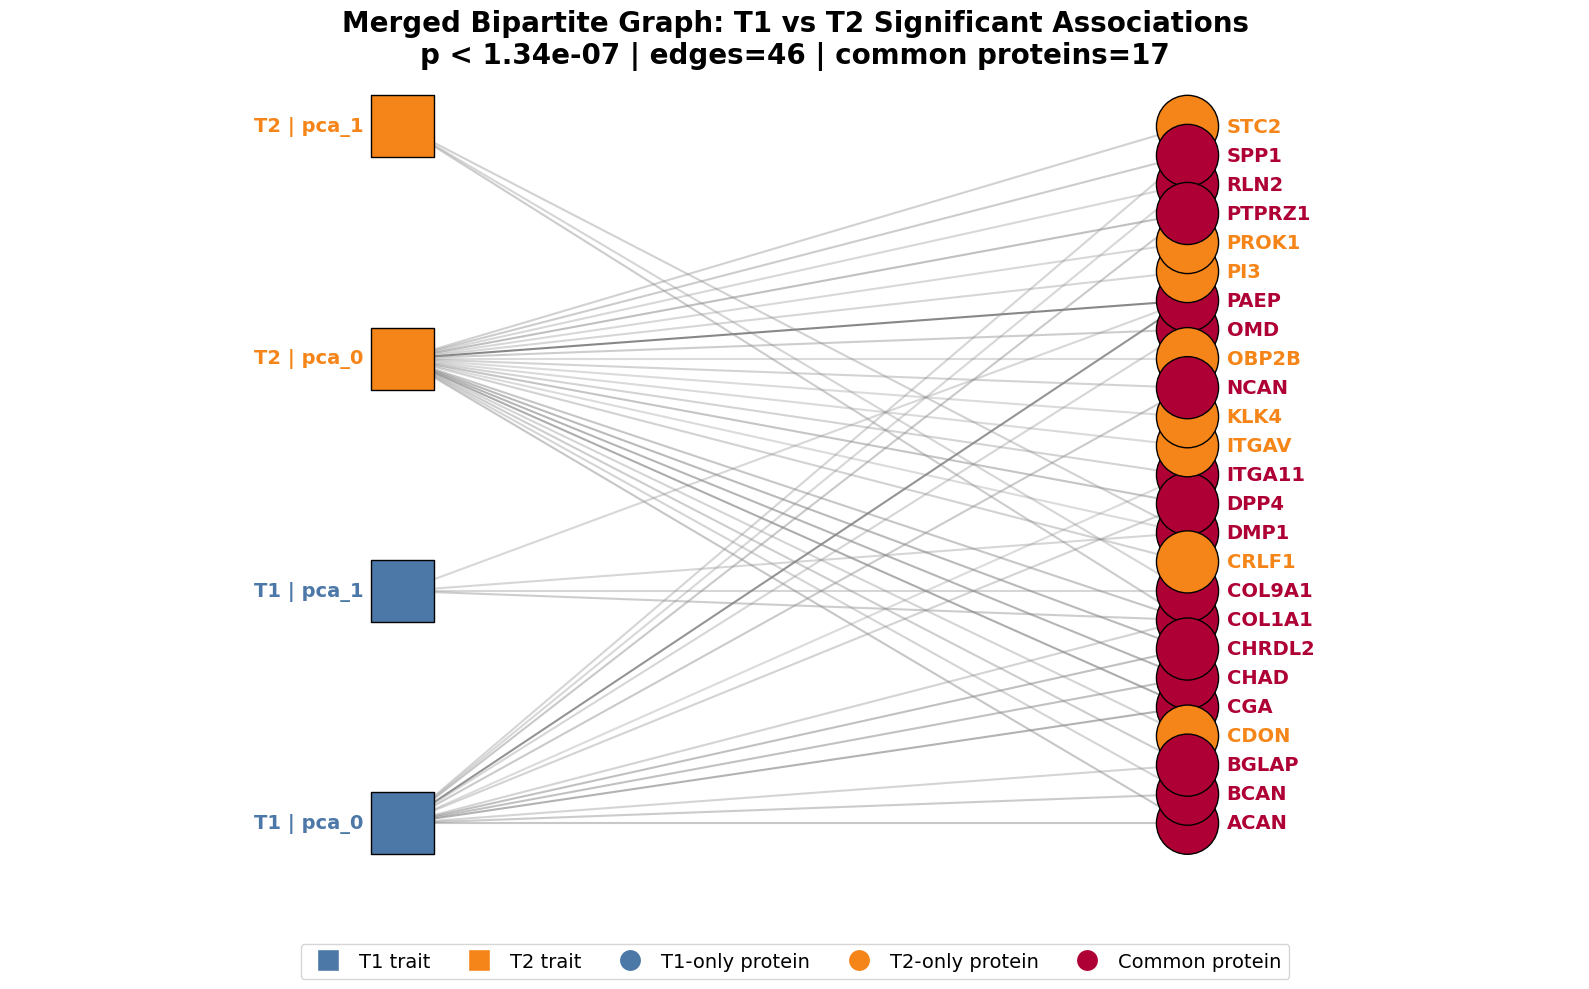

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

t1_file = "/data484_4/txia2/mocov2/proWAS/prowas_brain_LOD_mean/brain_prowas_all_traits.csv"
t2_file = "/data484_4/txia2/mocov2/proWAS/prowas_brain_T2_LOD_mean/brain_prowas_all_traits.csv"

t1_df = pd.read_csv(t1_file)
t2_df = pd.read_csv(t2_file)

bonferroni_threshold = 0.05 / (128 * 2923)
print(f"Bonferroni correction threshold: {bonferroni_threshold:.2e}")

t1_sig = t1_df[t1_df["p_value"] < bonferroni_threshold].copy()
t2_sig = t2_df[t2_df["p_value"] < bonferroni_threshold].copy()
print(f"T1 significant associations: {len(t1_sig)}")
print(f"T2 significant associations: {len(t2_sig)}")

if len(t1_sig) == 0 and len(t2_sig) == 0:
    print("No significant associations available to plot.")
else:
    edge_payload: dict[tuple[str, str], dict[str, list[float]]] = {}

    def accumulate_edges(sig_df: pd.DataFrame, cohort: str) -> None:
        for trait, protein, pval in sig_df[["trait", "protein", "p_value"]].itertuples(index=False):
            key = (trait, protein)
            cohort_bucket = edge_payload.setdefault(key, {})
            cohort_bucket.setdefault(cohort, []).append(-np.log10(pval))

    accumulate_edges(t1_sig, "T1")
    accumulate_edges(t2_sig, "T2")

    G = nx.Graph()
    plotted_edges: list[tuple[str, str, float, str, bool]] = []

    for (trait, protein), cohorts in edge_payload.items():
        is_common = len(cohorts) > 1
        for cohort, weights in cohorts.items():
            trait_node = f"{cohort} | {trait}"
            avg_weight = float(np.mean(weights))
            G.add_node(trait_node, bipartite=0, cohort=cohort, trait=trait)
            G.add_node(protein, bipartite=1)
            G.add_edge(trait_node, protein, weight=avg_weight)
            plotted_edges.append((trait_node, protein, avg_weight, cohort, is_common))

    features = {n for n, d in G.nodes(data=True) if d["bipartite"] == 0}
    proteins = {n for n, d in G.nodes(data=True) if d["bipartite"] == 1}

    t1_proteins = set(t1_sig["protein"])
    t2_proteins = set(t2_sig["protein"])
    common_proteins = t1_proteins & t2_proteins
    t1_only = t1_proteins - t2_proteins
    t2_only = t2_proteins - t1_proteins

    common_df = pd.DataFrame(sorted(list(common_proteins)), columns=["common_protein"])
    common_output_path = "/data484_4/txia2/mocov2/proWAS/protein_common_analysis/common_proteins_LOD_mean.csv"
    common_df.to_csv(common_output_path, index=False)
    print(f"Common proteins saved to: {common_output_path}")

    max_nodes_in_col = max(len(features), len(proteins))
    dynamic_height = max(10, max_nodes_in_col * 0.4)

    fig, ax = plt.subplots(figsize=(16, dynamic_height))

    pos: dict[str, tuple[float, float]] = {}
    sorted_features = sorted(features)
    sorted_proteins = sorted(proteins)

    for i, node in enumerate(sorted_features):
        pos[node] = (0, i / max(len(sorted_features) - 1, 1))

    for i, node in enumerate(sorted_proteins):
        pos[node] = (1, i / max(len(sorted_proteins) - 1, 1))

    edge_weights = [w for _, _, w, _, _ in plotted_edges]
    if edge_weights:
        max_weight = max(edge_weights)
        min_weight = min(edge_weights)
        if max_weight == min_weight:
            alphas = [0.5] * len(edge_weights)
        else:
            alphas = [0.3 + 0.7 * (w - min_weight) / (max_weight - min_weight) for w in edge_weights]
    else:
        alphas = []

    for (edge, alpha) in zip(plotted_edges, alphas):
        u, v, weight, cohort, is_common = edge
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            width=1.5,
            edge_color="#888888",
            alpha=alpha,
            ax=ax,
        )

    def feature_color(node: str) -> str:
        if node.startswith("T1 | "):
            return "#4C78A8"
        if node.startswith("T2 | "):
            return "#F58518"
        return "#708090"

    feature_nodes = list(features)
    feature_colors = [feature_color(node) for node in feature_nodes]
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=feature_nodes,
        node_color=feature_colors,
        node_size=2000,
        node_shape="s",
        ax=ax,
        edgecolors="black",
    )

    def protein_color(node: str) -> str:
        if node in common_proteins:
            return "#AF0035"
        if node in t1_only:
            return "#4C78A8"
        return "#F58518"

    protein_nodes = list(proteins)
    protein_colors = [protein_color(node) for node in protein_nodes]

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=protein_nodes,
        node_color=protein_colors,
        node_size=2000,
        node_shape="o",
        ax=ax,
        edgecolors="black",
    )

    x_offset = 0.05
    pos_features_text = {n: (x - x_offset, y) for n, (x, y) in pos.items() if n in features}
    pos_proteins_text = {n: (x + x_offset, y) for n, (x, y) in pos.items() if n in proteins}

    def draw_feature_labels(nodes: set[str], color: str) -> None:
        if not nodes:
            return
        subset_pos = {n: pos_features_text[n] for n in nodes}
        labels = {n: n for n in nodes}
        nx.draw_networkx_labels(
            G,
            subset_pos,
            labels=labels,
            font_size=14,
            horizontalalignment="right",
            verticalalignment="center",
            font_weight="bold",
            font_color=color,
            ax=ax,
        )

    t1_feature_nodes = {n for n in feature_nodes if n.startswith("T1 | ")}
    t2_feature_nodes = {n for n in feature_nodes if n.startswith("T2 | ")}

    draw_feature_labels(t1_feature_nodes, "#4C78A8")
    draw_feature_labels(t2_feature_nodes, "#F58518")

    def draw_label_subset(nodes: set[str], color: str) -> None:
        if not nodes:
            return
        subset_pos = {n: pos_proteins_text[n] for n in nodes}
        labels = {n: n for n in nodes}
        nx.draw_networkx_labels(
            G,
            subset_pos,
            labels=labels,
            font_size=14,
            horizontalalignment="left",
            verticalalignment="center",
            font_weight="bold",
            font_color=color,
            ax=ax,
        )

    draw_label_subset(common_proteins, "#AF0035")
    draw_label_subset(t1_only, "#4C78A8")
    draw_label_subset(t2_only, "#F58518")

    ax.set_title(
        "Merged Bipartite Graph: T1 vs T2 Significant Associations\n"
        f"p < {bonferroni_threshold:.2e} | edges={len(plotted_edges)} | common proteins={len(common_proteins)}",
        fontsize=20,
        weight="bold",
        pad=20,
    )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.05, 1.05)
    ax.axis("off")

    legend_handles = [
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#4C78A8", markersize=16, label="T1 trait"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#F58518", markersize=16, label="T2 trait"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C78A8", markersize=16, label="T1-only protein"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#F58518", markersize=16, label="T2-only protein"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#AF0035", markersize=16, label="Common protein"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=5,
        fontsize=14,
        columnspacing=1.5,
        handletextpad=0.6,
    )

    plt.tight_layout()

    output_path = "/data484_4/txia2/mocov2/proWAS/prowas_brain_LOD_mean/bipartite_graph_significant_merged.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"\nMerged figure saved to: {output_path}")

    plt.show()
